# 02 — Dixon-Coles model

Fit attack/defense ratings with time decay and a low-score correction, then predict match scorelines and outcomes.

In [82]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize

In [83]:
df = pd.read_parquet('../data/processed/results_clean.parquet')
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,2006-01-02,Qatar,Libya,2,0,Friendly,Doha,Qatar,False
1,2006-01-05,Egypt,Zimbabwe,2,0,Friendly,Alexandria,Egypt,False
2,2006-01-07,Guinea,Togo,1,0,Friendly,Viry-Châtillon,France,True
3,2006-01-09,Morocco,DR Congo,3,0,Friendly,Rabat,Morocco,False
4,2006-01-11,Ghana,Togo,0,1,Friendly,Monastir,Tunisia,True


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18989 entries, 0 to 18988
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        18989 non-null  datetime64[us]
 1   home_team   18989 non-null  str           
 2   away_team   18989 non-null  str           
 3   home_score  18989 non-null  int64         
 4   away_score  18989 non-null  int64         
 5   tournament  18989 non-null  str           
 6   city        18989 non-null  str           
 7   country     18989 non-null  str           
 8   neutral     18989 non-null  bool          
dtypes: bool(1), datetime64[us](1), int64(2), str(5)
memory usage: 2.1 MB


## Fit the model

Build team indices and time-decay weights, define the negative log-likelihood and its gradient, and optimize with L-BFGS-B.

In [85]:
teams = sorted(set(df["home_team"]) | set(df["away_team"]))
idx = {t: i for i, t in enumerate(teams)}
n = len(teams)

hi = np.asarray(df["home_team"].map(idx), dtype=np.int64)
ai = np.asarray(df["away_team"].map(idx), dtype=np.int64)
hg = np.asarray(df["home_score"], dtype=np.int64)
ag = np.asarray(df["away_score"], dtype=np.int64)

xi = 0.0005
days_ago = np.asarray((df["date"].max() - df["date"]).dt.days, dtype=float)
w = np.exp(-xi * days_ago)

print(f"{n} teams, {len(hi)} matches")

226 teams, 18989 matches


In [86]:
# the four low-score cells where the Dixon-Coles correction applies
m00 = (hg==0)&(ag==0); m01 = (hg==0)&(ag==1)
m10 = (hg==1)&(ag==0); m11 = (hg==1)&(ag==1)

def unpack(p):
    att = np.concatenate([p[:n-1], [-p[:n-1].sum()]])  # attack sums to zero
    dfn = p[n-1:2*n-1]
    home_adv = p[2*n-1]
    rho = p[2*n]
    return att, dfn, home_adv, rho

def tau_terms(lam, mu, rho):
    tau = np.ones_like(lam)
    tau[m00] = 1 - lam[m00]*mu[m00]*rho
    tau[m01] = 1 + lam[m01]*rho
    tau[m10] = 1 + mu[m10]*rho
    tau[m11] = 1 - rho
    return np.clip(tau, 1e-10, None)

def neg_log_lik(p):
    att, dfn, home_adv, rho = unpack(p)
    log_lam = np.clip(home_adv + att[hi] + dfn[ai], -10, 10)
    log_mu  = np.clip(att[ai] + dfn[hi], -10, 10)
    lam, mu = np.exp(log_lam), np.exp(log_mu)
    tau = tau_terms(lam, mu, rho)
    ll = hg*log_lam - lam + ag*log_mu - mu + np.log(tau)   # Poisson log-prob + correction
    return -np.sum(w * ll)

In [87]:
def grad(p):
    att, dfn, home_adv, rho = unpack(p)
    lam = np.exp(np.clip(home_adv + att[hi] + dfn[ai], -10, 10))
    mu  = np.exp(np.clip(att[ai] + dfn[hi], -10, 10))
    tau = tau_terms(lam, mu, rho)

    # how tau changes in the four corrected cells (zero everywhere else)
    dl = np.zeros_like(lam); dm = np.zeros_like(lam); dr = np.zeros_like(lam)
    dl[m00] = -mu[m00]*rho; dm[m00] = -lam[m00]*rho; dr[m00] = -lam[m00]*mu[m00]
    dl[m01] = rho;          dr[m01] = lam[m01]
    dm[m10] = rho;          dr[m10] = mu[m10]
    dr[m11] = -1.0

    # per-match "score": how much each match wants to move each rate
    S_lam = w * (hg - lam + (lam/tau)*dl)
    S_mu  = w * (ag - mu + (mu/tau)*dm)
    S_rho = w * (dr / tau)

    g_att = -(np.bincount(hi, S_lam, n) + np.bincount(ai, S_mu, n))
    g_def = -(np.bincount(ai, S_lam, n) + np.bincount(hi, S_mu, n))
    g_ha  = -np.sum(S_lam)
    g_rho = -np.sum(S_rho)
    g_free = g_att[:n-1] - g_att[n-1]      # chain rule for the sum-to-zero attack
    return np.concatenate([g_free, g_def, [g_ha], [g_rho]])

In [88]:
x0 = np.concatenate([np.zeros(n-1), np.zeros(n), [0.25], [0.0]])
bounds = [(None, None)]*(2*n-1) + [(None, None), (-0.1, 0.1)]   # only ρ is bounded

res = minimize(neg_log_lik, x0, jac=grad, method="L-BFGS-B",
               bounds=bounds, options={"maxiter": 500})
att, dfn, home_adv, rho = unpack(res.x)
print("converged:", res.success)
print(f"home advantage = {home_adv:.3f}")
print(f"rho            = {rho:.4f}")

converged: True
home advantage = 0.253
rho            = -0.0506


## Team ratings

Attack and defense ratings, ranked.

In [89]:
ratings = pd.DataFrame({"team": teams, "attack": att, "defense": dfn})

print("TOP 10 ATTACK")
print(ratings.sort_values("attack", ascending=False).head(10).to_string(index=False))
print("\nBEST 10 DEFENSE (most negative = fewest conceded)")
print(ratings.sort_values("defense").head(10).to_string(index=False))

TOP 10 ATTACK
       team   attack   defense
      Spain 1.364633 -1.230865
    Germany 1.332194 -0.839271
     Brazil 1.331792 -1.201670
     France 1.248925 -1.133856
   Portugal 1.244087 -1.081174
Netherlands 1.236859 -0.921738
    Belgium 1.219633 -0.969009
  Argentina 1.194663 -1.429990
    England 1.178800 -1.265176
   Colombia 1.120500 -1.104675

BEST 10 DEFENSE (most negative = fewest conceded)
     team   attack   defense
Argentina 1.194663 -1.429990
  England 1.178800 -1.265176
    Spain 1.364633 -1.230865
  Morocco 0.789465 -1.213290
   Brazil 1.331792 -1.201670
   France 1.248925 -1.133856
 Colombia 1.120500 -1.104675
  Uruguay 0.902678 -1.093399
 Portugal 1.244087 -1.081174
  Ecuador 0.753957 -1.058065


## Predict a match

Expected goals, scoreline matrix, and W/D/L probabilities.

In [90]:
from scipy.stats import poisson

def expected_goals(home, away, neutral=False):
    h, a = idx[home], idx[away]
    adv = 0.0 if neutral else home_adv          # no advantage on neutral ground
    lam = np.exp(adv + att[h] + dfn[a])         # expected goals for home team
    mu  = np.exp(att[a] + dfn[h])               # expected goals for away team
    return lam, mu

def score_matrix(home, away, neutral=False, max_goals=10):
    lam, mu = expected_goals(home, away, neutral)
    i = np.arange(max_goals + 1)
    mat = np.outer(poisson.pmf(i, lam), poisson.pmf(i, mu))   # independent Poisson
    mat[0, 0] *= 1 - lam*mu*rho                  # Dixon-Coles correction
    mat[0, 1] *= 1 + lam*rho
    mat[1, 0] *= 1 + mu*rho
    mat[1, 1] *= 1 - rho
    mat /= mat.sum()                             # renormalize
    return mat

def predict(home, away, neutral=False):
    mat = score_matrix(home, away, neutral)
    return {
        "home_win": np.tril(mat, -1).sum(),   # home scores more (below diagonal)
        "draw":     np.trace(mat),            # on the diagonal
        "away_win": np.triu(mat, 1).sum(),    # away scores more (above diagonal)
    }


## Example + heatmap

Pick a matchup and visualize its scoreline distribution.

In [105]:
home, away = "Croatia", "Panama"
neutral = True

lam, mu = expected_goals(home, away, neutral)
p = predict(home, away, neutral)

print(f"{home} vs {away}  (neutral={neutral})")
print(f"Expected goals:  {home} {lam:.2f} - {mu:.2f} {away}\n")
print(f"{home} win:          {p['home_win']*100:.1f}%")
print(f"Draw:                {p['draw']*100:.1f}%")
print(f"{away} win:          {p['away_win']*100:.1f}%")


Croatia vs Panama  (neutral=True)
Expected goals:  Croatia 1.97 - 0.66 Panama

Croatia win:          67.9%
Draw:                21.0%
Panama win:          11.0%


Most likely scorelines:
  Croatia 2-0 Panama:  14.0%
  Croatia 1-0 Panama:  13.7%
  Croatia 1-1 Panama:  9.8%
  Croatia 2-1 Panama:  9.2%
  Croatia 3-0 Panama:  9.2%
  Croatia 0-0 Panama:  7.7%
  Croatia 3-1 Panama:  6.1%
  Croatia 4-0 Panama:  4.5%


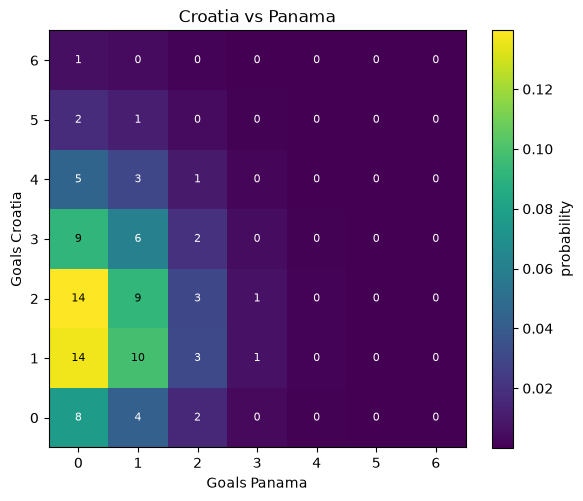

In [106]:
import matplotlib.pyplot as plt

mat = score_matrix(home, away, neutral)

# most likely scorelines
cells = [(i, j, mat[i, j]) for i in range(7) for j in range(7)]
cells.sort(key=lambda x: x[2], reverse=True)
print("Most likely scorelines:")
for i, j, prob in cells[:8]:
    print(f"  {home} {i}-{j} {away}:  {prob*100:.1f}%")

# heatmap
m = mat[:7, :7]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(m, origin="lower", cmap="viridis")
ax.set_xlabel(f"Goals {away}"); ax.set_ylabel(f"Goals {home}")
ax.set_xticks(range(7)); ax.set_yticks(range(7))
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{m[i,j]*100:.0f}", ha="center", va="center",
                color="white" if m[i,j] < m.max()*0.6 else "black", fontsize=8)
fig.colorbar(im, label="probability")
plt.title(f"{home} vs {away}")
plt.tight_layout(); plt.show()
